# Physics-informed neural networks (PINNs): an introductory crash-course

By Ben Moseley, 2022

This workshop builds upon my blog post on PINNs: https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/. 

Read the seminal PINN papers [here](https://ieeexplore.ieee.org/document/712178) and [here](https://www.sciencedirect.com/science/article/pii/S0021999118307125).


## Workshop goals

By the end of this workshop, you should be able to:
- code a PINN from scratch in PyTorch
- understand the different types of scientific tasks PINNs can be used for
- understand in more detail how PINNs are trained and how to improve their convergence


## Task overview

We will be coding a PINN from scratch in PyTorch and using it solve simulation and inversion tasks related to the damped harmonic oscillator.


## Problem overview

We are going to use a PINN to solve problems related to the **damped harmonic oscillator**:

<img src="oscillator.gif" width="500">

We are interested in modelling the displacement of the mass on a spring (green box) over time.

This is a canonical physics problem, where the displacement, $u(t)$, of the oscillator as a function of time can be described by the following differential equation:

$$
m \dfrac{d^2 u}{d t^2} + \mu \dfrac{d u}{d t} + ku = 0~,
$$

where $m$ is the mass of the oscillator, $\mu$ is the coefficient of friction and $k$ is the spring constant.

We will focus on solving the problem in the **under-damped state**, i.e. where the oscillation is slowly damped by friction (as displayed in the animation above). 

Mathematically, this occurs when:

$$
\delta < \omega_0~,~~~~~\mathrm{where}~~\delta = \dfrac{\mu}{2m}~,~\omega_0 = \sqrt{\dfrac{k}{m}}~.
$$

Furthermore, we consider the following initial conditions of the system in the temporal range $t=[0,1]$:

$$
u(t=0) = 1~~,~~\dfrac{d u}{d t}(t=0) = 0~.
$$

For this particular case, the exact solution is known and given by:

$$
u(t) = e^{-\delta t}(2 A \cos(\phi + \omega t))~,~~~~~\mathrm{with}~~\omega=\sqrt{\omega_0^2 - \delta^2}~.
$$

To reduce the number of parameters in the neural networks, it is better to transform the above equation to the non-dimensional form. For that it is needed to follow the following steps:

1. Step: Identify independent and dependent variables:
   1. independent variable: $t$
   2. dependent variable: $u$
2. Step: Make the size of independent and dependent variables about unity AND Reduce the number of independent physical parameters in the model:
   
$$
\overline{u} = \dfrac{u-u_0}{u_{c}} = \dfrac{u}{u_{c}} => u = u_{c}*\overline{u} => du = u_{c}*d\overline{u};  \dfrac{du}{dt} = \dfrac{u_c}{t_c}*\dfrac{d\overline{u}}{d\overline{t}} ;  \dfrac{d^2 u}{d t^2} = \dfrac{d(\dfrac{du}{dt})}{d(dt)} = \dfrac{u_c}{t_c^2}*\dfrac{d^2\overline{u}}{d\overline{t}^2} 
$$

$$
\overline{t} = \dfrac{t-t_0}{t_c} = \dfrac{t}{t_c} => t = t_c*\overline{t} => dt = t_c*d\overline{t}
$$

$$
\dfrac{d^2 u}{d t^2} + \frac{\mu}{m}\dfrac{d u}{d t} + \dfrac{k}{m}u = 0~ ; 
$$

$$
\dfrac{u_c}{t_c^2}*\dfrac{d^2\overline{u}}{d\overline{t}^2} + \frac{\mu}{m}\dfrac{u_c}{t_c}*\dfrac{d\overline{u}}{d\overline{t}} + \dfrac{k}{m}u_{c}*\overline{u} = 0 ;
$$

$$
\dfrac{d^2\overline{u}}{d\overline{t}^2} + \frac{\mu t_c}{m}\dfrac{d\overline{u}}{d\overline{t}} + \dfrac{k t_c^2}{m}*\overline{u} = 0 ;
$$

with the non-dimensional boundary conditions:

$$
\overline{u}(\overline{t}=0) = \dfrac{1}{u_c}~~,~~\dfrac{d \overline{u}}{d \overline{t}}(\overline{t}=0) = 0 ~ (~0*\dfrac{t_c}{u_c})~.
$$

To assess $t_c$ is needed to focus on the right temporal scale, in our case on the oscillation term, making it equal to the unity. In this case we use the following equation:
$$
\dfrac{d^2\overline{u}}{d\overline{t}^2} + (\dfrac{k t_c^2}{m} \approx 1)*\overline{u} = 0 ;
$$

obtaining the characteristic time, $t_c$:
$$
t_c = \sqrt{\dfrac{m}{k}}
$$

With the characteristic time, $t_c$, it is possible now to obtain the temporal range in the dimensionless space:


$$
t = [0,1] ~~~~ -> ~~~~ \overline{t} = [0, \dfrac{1}{t_c}] = [0, \dfrac{1}{\sqrt{\dfrac{m}{k}}}] = [0, \dfrac{1}{\sqrt{\dfrac{min(m)}{max(k)}}}]
$$


The characteristic velocity $u_c$ appears only in the boundaty condition. In this case, it is straightforward to select a value to do it dimensionless:

$$
\overline{u}(\overline{t}=0) = \dfrac{1}{u_c}~~with~~u_c=1 -> \overline{u}(\overline{t}=0)=1.
$$

Substituying $t_c$ and $u_c$ within the original diffential equation, we obtain the dimensionless variant: 
$$
\dfrac{d^2\overline{u}}{d\overline{t}^2} + \frac{\mu}{\sqrt{k*m}}\dfrac{d\overline{u}}{d\overline{t}} + \overline{u} = 0 ;
$$

Seeing the dimensionless equation, we can define an dimensionless coefficient, $\overline{\mu}$:
$$
\overline{\mu}= \dfrac{\mu}{\sqrt{k*m}} 
$$
obtaining:
$$
\dfrac{d^2\overline{u}}{d\overline{t}^2} + \overline{\mu}*\dfrac{d\overline{u}}{d\overline{t}} + \overline{u} = 0 ;
$$
The dimensionless equation has the advantage of presenting only parameter $\overline{\mu}$, instead of 3 ($k$, $\mu$ and $m$). 
The last task is to obtain the range of $\overline{\mu}$ combining the ranges of $k$, $\mu$ and $m$. 

Question:
1. como estamos solo estudiando el caso underdamped, tendria que introducir una relacion entre los parametros para elegir los rangos?:
$$
\overline{\mu}= \dfrac{\mu}{\sqrt{k*m}}<1~-> \dfrac{\mu^2}{k} < m 
$$ 

More information about the universal oscillator equation and its nondimensionalization can be found here:
1. Harmonic Oscillator: https://en.wikipedia.org/wiki/Harmonic_oscillator
2. Nondimensionalization: https://en.wikipedia.org/wiki/Nondimensionalization


For a more detailed mathematical description of the harmonic oscillator, check out this blog post: https://beltoforion.de/en/harmonic_oscillator/.

# Workflow overview

There are **two scientific tasks** related to the harmonic oscillator we will use a PINN for:

>First, we will **simulate** the system using a PINN, given its initial conditions.

## Task 1: train a PINN to simulate the system

#### Task

The first task is to use a PINN to **simulate** the system.

Specifically, our inputs and outputs are:

- Inputs: underlying differential equation and the initial conditions of the system
- Outputs: estimate of the solution, $u(t)$

#### Approach

The PINN is trained to directly approximate the solution to the differential equation, i.e.

$$
u_{\mathrm{PINN}}(t;\theta) \approx u(t)~,
$$

where $\theta$ are the free parameters of the PINN.

#### Loss function

To simulate the system, the PINN is trained with the following loss function:

$$
\mathcal{L}(\theta)= (u_{\mathrm{PINN}}(t=0;\theta) - 1)^2 + \lambda_1 \left(\frac{d\,u_{\mathrm{PINN}}}{dt}(t=0;\theta) - 0\right)^2 + \frac{\lambda_2}{N} \sum^{N}_{i} \left( \left[ m\frac{d^2}{dt^2} + \mu \frac{d}{dt} + k \right] u_{\mathrm{PINN}}(t_{i};\theta)  \right)^2
$$

For this task, we use $\delta=2$, $\omega_0=20$, and try to learn the solution over the domain $t\in [0,1]$.

#### Notes

The first two terms in the loss function represent the **boundary loss**, and tries to ensure that the solution learned by the PINN matches the initial conditions of the system, namely, $u(t=0)=1$ and $u'(t=0)=0$.

The second term in the loss function is called the **physics loss**, and and tries to ensure that the PINN solution obeys the underlying differential equation at a set of training points $\{t_i\}$ sampled over the entire domain.

The hyperparameters, $\lambda_1$ and $\lambda_2$, are used to balence the terms in the loss function, to ensure stability during training.

Autodifferentiation (`torch.autograd`) is used to calculate the gradients of the PINN with respect to its input required to evaluate the loss function. This is very powerful! 

For more details on `torch.autograd`, check out [this](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html#a-gentle-introduction-to-torch-autograd) tutorial.

Here you can see an overview of the 2 dimensional space (t, mu):

<img src="excalidraw1.JPG" width="750">

## Step 1: Definition and initialization

In [1]:
### Import all what you need:
import torch
import torch.nn as nn
import torch.nn.init as init
from torchsummary import summary # https://pypi.org/project/torch-summary/
import torchinfo 

import random

import numpy as np

import matplotlib.pyplot as plt

import time

# IMPORTS FROM OTHER MODULES:
#from gauss_distribution import mu_adim
import gauss_distribution

import geometry

import training

import nn

import analytical_sol





In [2]:
# Parameter ranges
mu_range = [1,50]
k_range = [10 ,50]
mass_range = [0.5,100]

mu_std = 3
k_std = 3
mass_std = 3

# Number of points to generate by the normal distribution
num_points_normal_distri = 5000
# Number of bins(plots):
num_bins = 100
# Generate points based on the density using inverse transform sampling
mu_adim_num_points = 25  # Number of points to generate

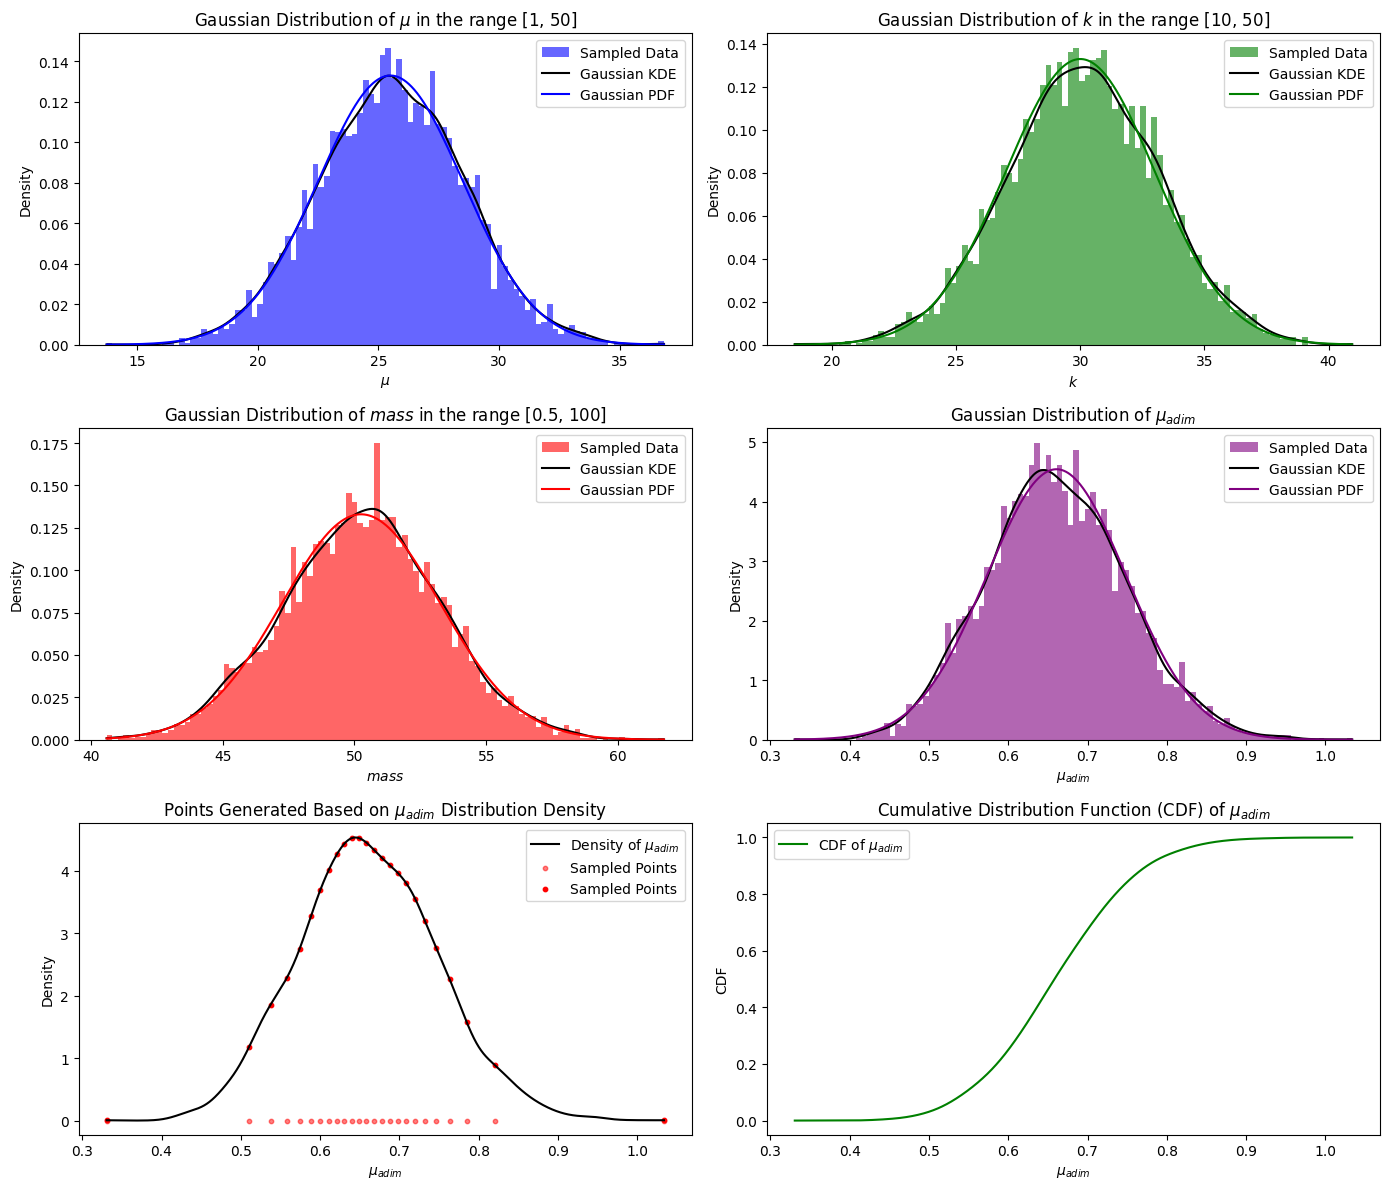

mu: 0 negative values.
k: 0 negative values.
mass: 0 negative values.
mu_adim: 0 negative values.
elapsed_time_count_negative: 0.0008876323699951172
elapsed_time_plot: 3.007775068283081


In [3]:
# Generate adimensional values of mu (mu_adim_sampled

mu_adim_sampled, mass_min, k_max = gauss_distribution.mu_adim(
    mu_range = mu_range, 
    mu_std = mu_std, 
    k_range= k_range, 
    k_std = k_std, 
    mass_range = mass_range, 
    mass_std = mass_std, 
    num_points_normal_distri = num_points_normal_distri, 
    num_points_mu_adim = mu_adim_num_points, 
    truncated_distribution = False, 
    num_bins = num_bins
)


In [4]:
# Pseudorandom number generator:
torch.manual_seed(123)

In [5]:
#Definition of the physical constants and hyperparameters:
mass = 1
d, w0 = 2, 20
mu, k = 2*d, mass*w0**2            # Este mu NO se utiliza!!!!!
k

400

### Initial, training and test points generation:

#### Initial condition 1: generation of initial points:
$$ u(t=0, \mu) = 1
$$
#### Initial condition 2: t and mu training points generation:
$$
\dfrac{d u}{d t}(t=0, \mu) = 0~
$$


#### Generation of physical domain training points: 

In [6]:
init_cond_mu_interval= (1,10) #ONLY for dimension equation
t_interval= (0,1)
physic_t_interval= (1e-4,1)

In [7]:
point_resolution, ic1_t_mu, ic1_scope, ic2_t_mu, ic2_scope, physic_in_t_mu, physic_domain_t_mu = geometry.point_generation(init_cond_mu_interval= init_cond_mu_interval, physic_t_interval= physic_t_interval, point_resolution_range= (10,50))
physic_in_t_mu
point_resolution

30

#### ADIM Generation of physical domain training points: 

In [8]:
# Min. Characteristic time -> used to define the max. t_adim range
t_charac_min = torch.sqrt(mass_min/k_max).item()

In [9]:
# ADIM init_cond_mu_interval
t_adim_max = 1/t_charac_min
t_adim_interval=(0, t_adim_max)
physic_t_adim_interval=(1e-4, t_adim_max)
physic_t_adim_interval

(0.0001, 1.0043561448809237)

In [10]:
mu_adim_sampled

tensor([0.3308, 0.5103, 0.5376, 0.5576, 0.5742, 0.5884, 0.6001, 0.6108, 0.6211,
        0.6304, 0.6396, 0.6489, 0.6582, 0.6680, 0.6777, 0.6875, 0.6982, 0.7085,
        0.7202, 0.7324, 0.7466, 0.7632, 0.7847, 0.8203, 1.0332],
       dtype=torch.float16)

In [11]:
#point_resolution, ic1_t_mu, ic1_scope, ic2_t_mu, ic2_scope, physic_in_t_mu, physic_domain_t_mu = geometry.adim_point_generation(physic_t_adim_interval= physic_t_adim_interval, point_resolution_range_t = 50)
physic_in_t_mu
point_resolution

30

#### Generation of testing points:

In [12]:
test_point_resolution, test_ic1_t_mu, test_ic1_scope, test_ic2_t_mu, test_ic2_scope, test_physic_in_t_mu, test_physic_domain_t_mu = geometry.point_generation(init_cond_mu_interval=init_cond_mu_interval, physic_t_interval=physic_t_interval, point_resolution_range=(50,100))
test_point_resolution

86

### Exact solution:

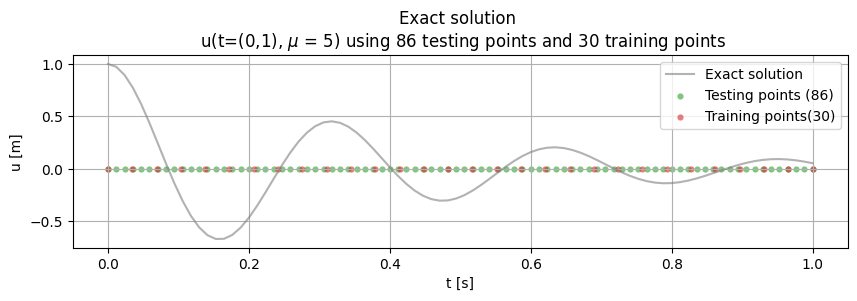

In [13]:
test_mu = 5
u_exact = analytical_sol.exact_solution(test_mu/(2*mass), w0, test_physic_in_t_mu[0])
# Plotting the exact solution:
plt.figure(figsize=(10,2.5))
plt.plot(
        test_physic_in_t_mu[0].detach(), 
        u_exact.detach(), 
        label="Exact solution", 
        color="tab:grey", 
        alpha=0.6)
plt.scatter(
        test_physic_in_t_mu[0].detach(), 
        torch.zeros_like(test_physic_in_t_mu[0]), 
        s=20, 
        lw=0, 
        color="tab:green",
        alpha=0.6,
        label= f"Testing points ({test_point_resolution})")
plt.scatter(
        physic_in_t_mu[0].detach(), 
        torch.zeros_like(physic_in_t_mu[0]), 
        s=20, 
        lw=0, 
        color="tab:red",
        alpha=0.6,
        label= f"Training points({point_resolution})")

plt.title(f"Exact solution \n u(t=(0,1), $\mu$ = {test_mu}) using {test_point_resolution} testing points and {point_resolution} training points")
plt.xlabel('t [s]')
plt.ylabel('u [m]')
plt.grid()
plt.legend()
plt.show()

## Step 2: Create Fully Connected Neural Network Class (FCNN):

## STEP 3: Instantiate the Model Class

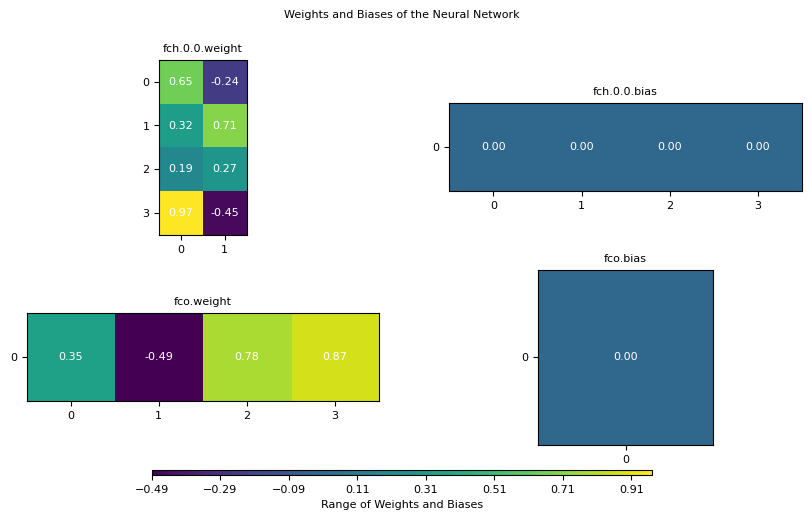

In [14]:
original_input_size = 2
original_hidden_layers =[4] # [4] #[64,64,64,64]
original_output_size = 1
original_model = nn.FCN(original_input_size, original_hidden_layers, original_output_size, activation='Tanh', initialization='Xavier')
#original_model.plot_weights()

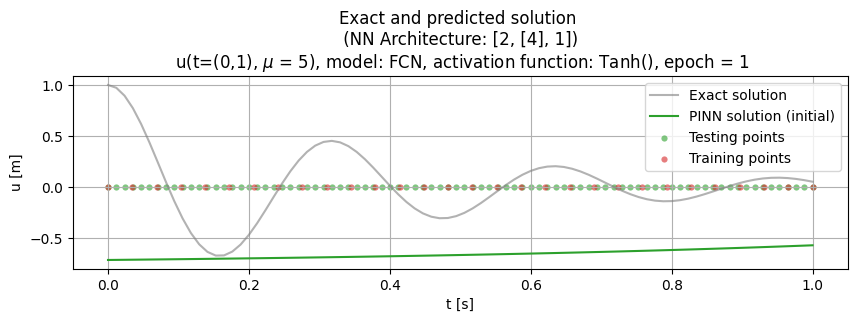

In [15]:
test_mu = 5
u_exact = analytical_sol.exact_solution(test_mu/(2*mass), w0, test_physic_in_t_mu[0])
test_in_t_constant_mu = torch.stack([torch.linspace(0,1,test_point_resolution), test_mu*torch.ones(test_point_resolution)], -1).view(-1,2)
test_predicted = original_model(test_in_t_constant_mu)

# Plotting the exact solution:
plt.figure(figsize=(10,2.5))
plt.plot(
        test_physic_in_t_mu[0].detach(), 
        u_exact.detach(), 
        label="Exact solution", 
        color="tab:grey", 
        alpha=0.6)
plt.plot(test_physic_in_t_mu[0].detach(), 
        test_predicted[:,0].detach(), 
        label="PINN solution (initial)", 
        color="tab:green"
)
plt.scatter(
        test_physic_in_t_mu[0].detach(), 
        torch.zeros_like(test_physic_in_t_mu[0]), 
        s=20, 
        lw=0, 
        color="tab:green",
        alpha=0.6,
        label= "Testing points")
plt.scatter(
        physic_in_t_mu[0].detach(), 
        torch.zeros_like(physic_in_t_mu[0]), 
        s=20, 
        lw=0, 
        color="tab:red",
        alpha=0.6,
        label= "Training points")
plt.title(f"Exact and predicted solution \n (NN Architecture: [{original_input_size}, {original_hidden_layers}, {original_output_size}]) \n u(t=(0,1), $\mu$ = {test_mu}), model: {original_model.__class__.__name__}, activation function: {original_model.activation}, epoch = 1")
#plt.title(f"Exact solution \n u(t=(0,1), $\mu$ = {test_mu}) using {test_point_resolution} testing points")
plt.xlabel('t [s]')
plt.ylabel('u [m]')
plt.grid()
plt.legend()
plt.show()

## STEP 4: Training the PINN

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initial state using a constant mu(5)


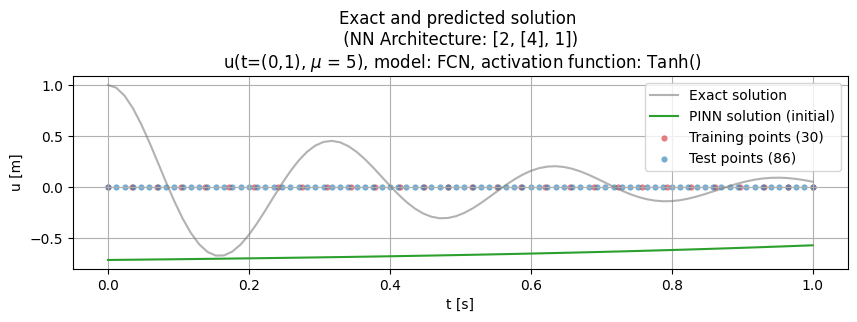

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
########################################################################################################################################################################################################
PLOTTING THE RESULTS FOR EPOCH: 1000
Maximum stagnation amplitude by the loss convergence: 0.015755504369735718
Decomposition of the TRAINING loss terms: 
 loss(0.42589038610458374) = loss1(0.16771899163722992) + 1 * loss2(0.034675583243370056) + 1 * loss3(0.22349581122398376)
Decomposition of the TEST loss terms: 
 loss(0.4252452254295349) = loss1(0.16671624779701233) + 1 * loss2(0.03450571745634079) + 1 * loss3(0.2240232527256012)


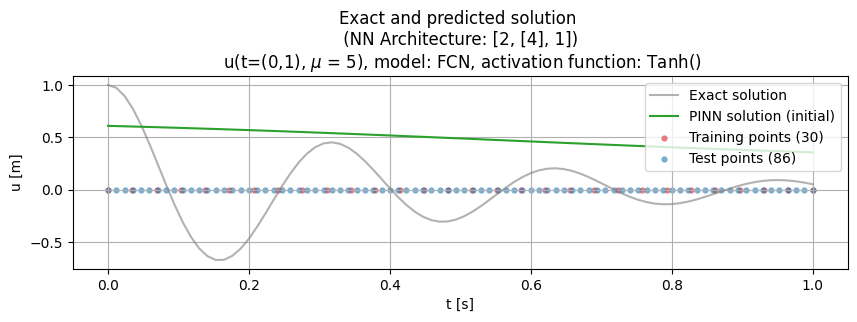

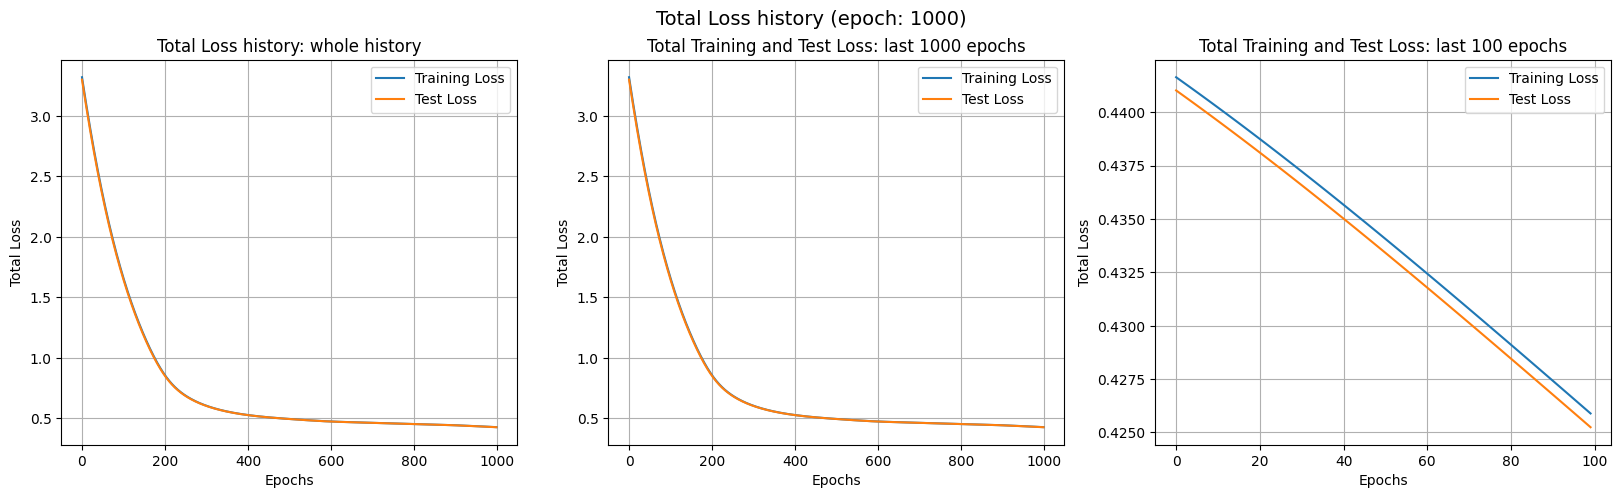

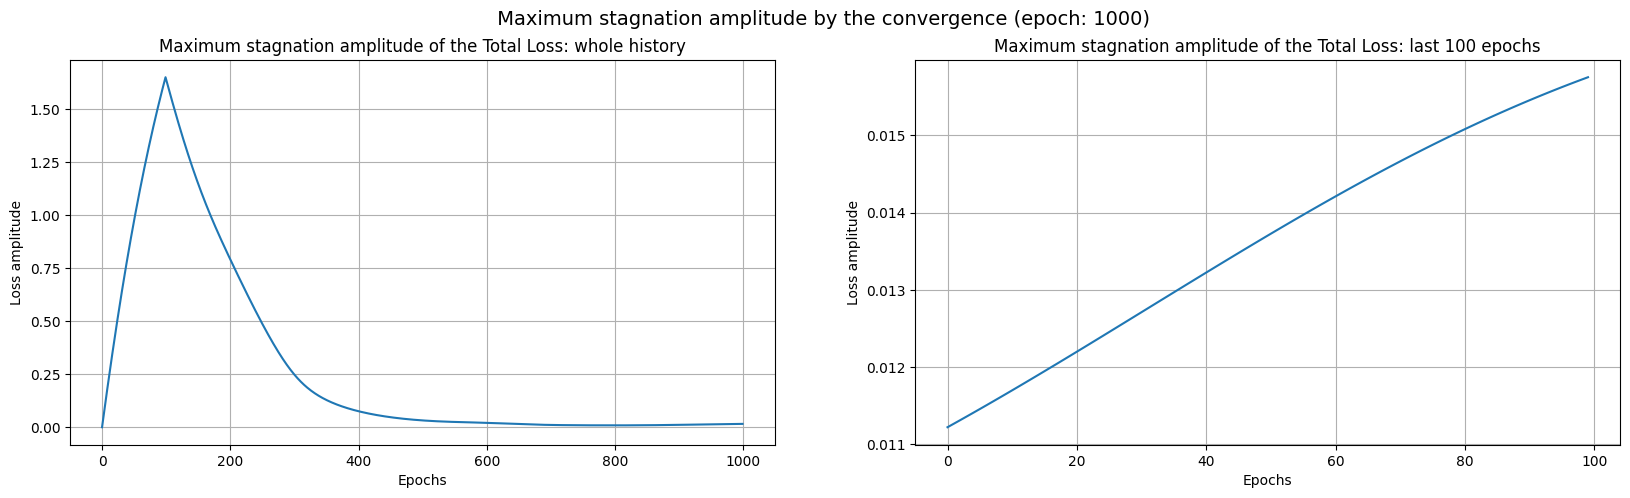

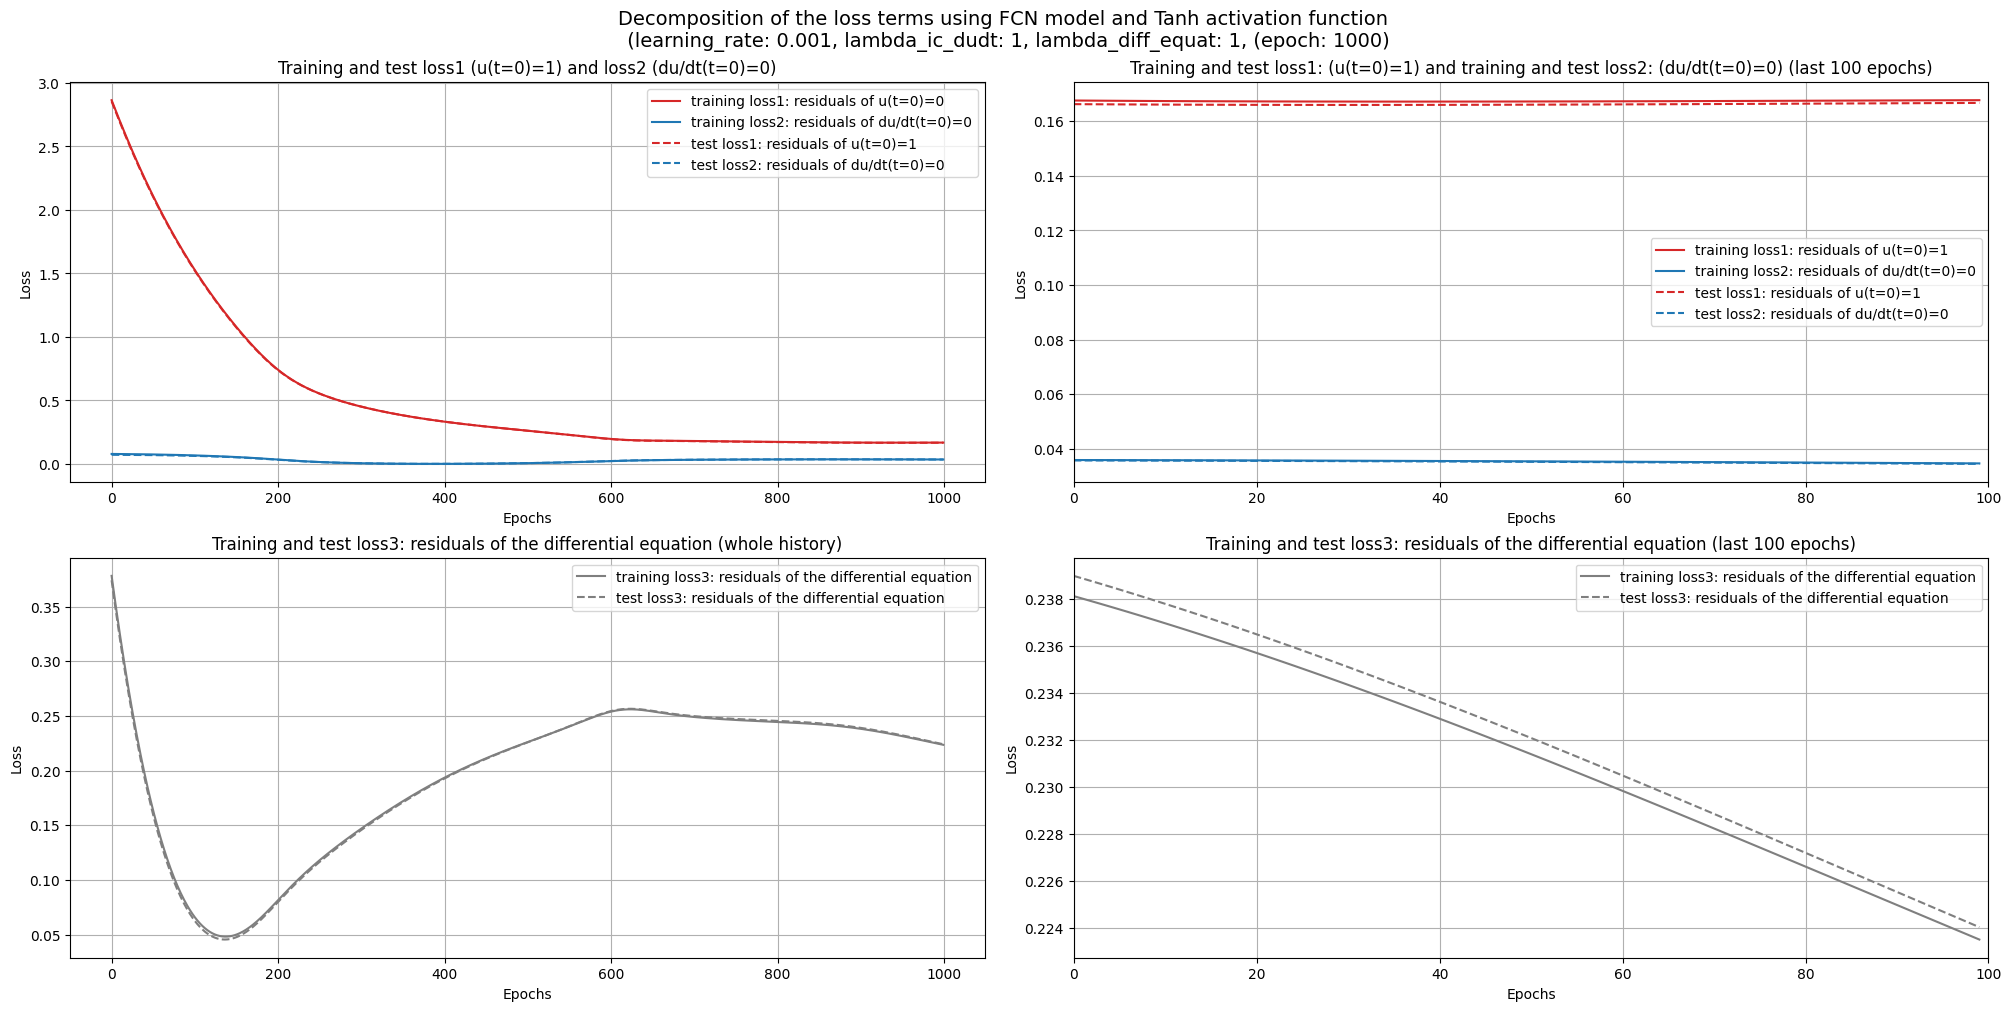

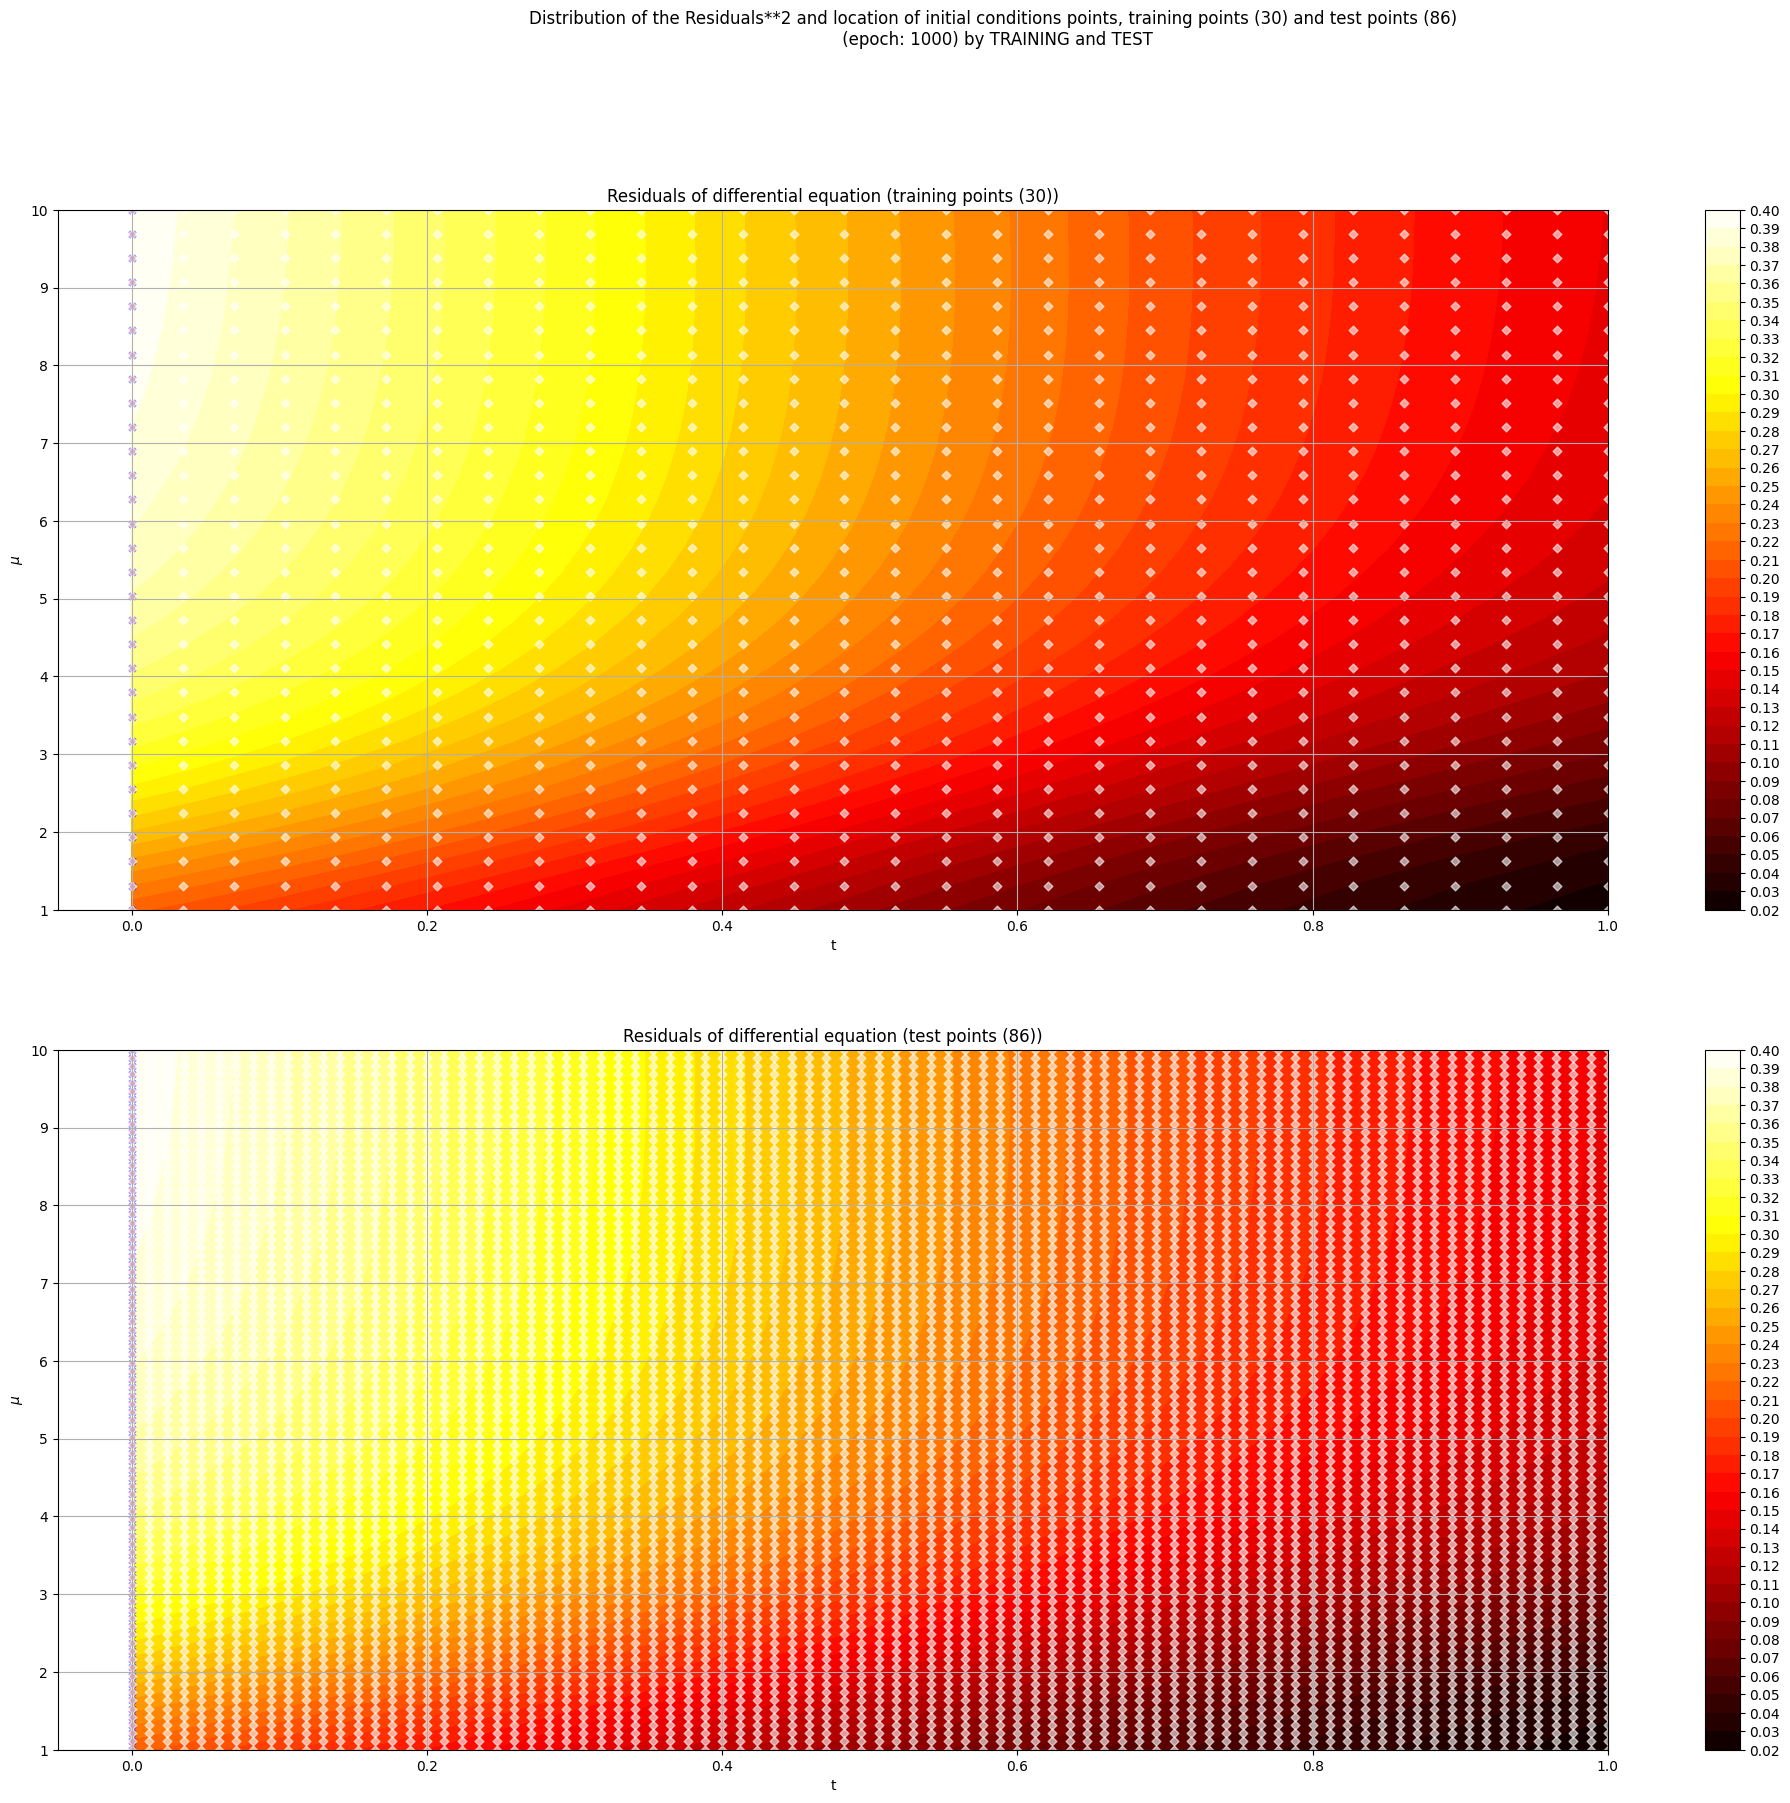

Saved the checkpoint corresponding to epoch: 1000
RESULTS PLOTTED FOR EPOCH: 1000
########################################################################################################################################################################################################
########################################################################################################################################################################################################
PLOTTING THE RESULTS FOR EPOCH: 2000
Maximum stagnation amplitude by the loss convergence: 0.011958181858062744
Decomposition of the TRAINING loss terms: 
 loss(0.28810781240463257) = loss1(0.10431831330060959) + 1 * loss2(0.01933923177421093) + 1 * loss3(0.1644502729177475)
Decomposition of the TEST loss terms: 
 loss(0.28655070066452026) = loss1(0.10455834865570068) + 1 * loss2(0.019228141754865646) + 1 * loss3(0.16276422142982483)


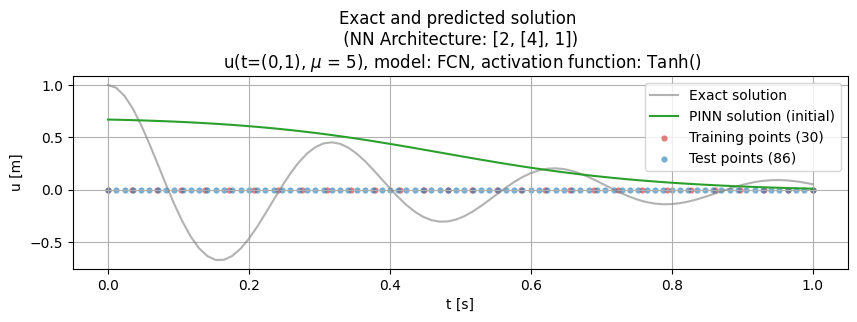

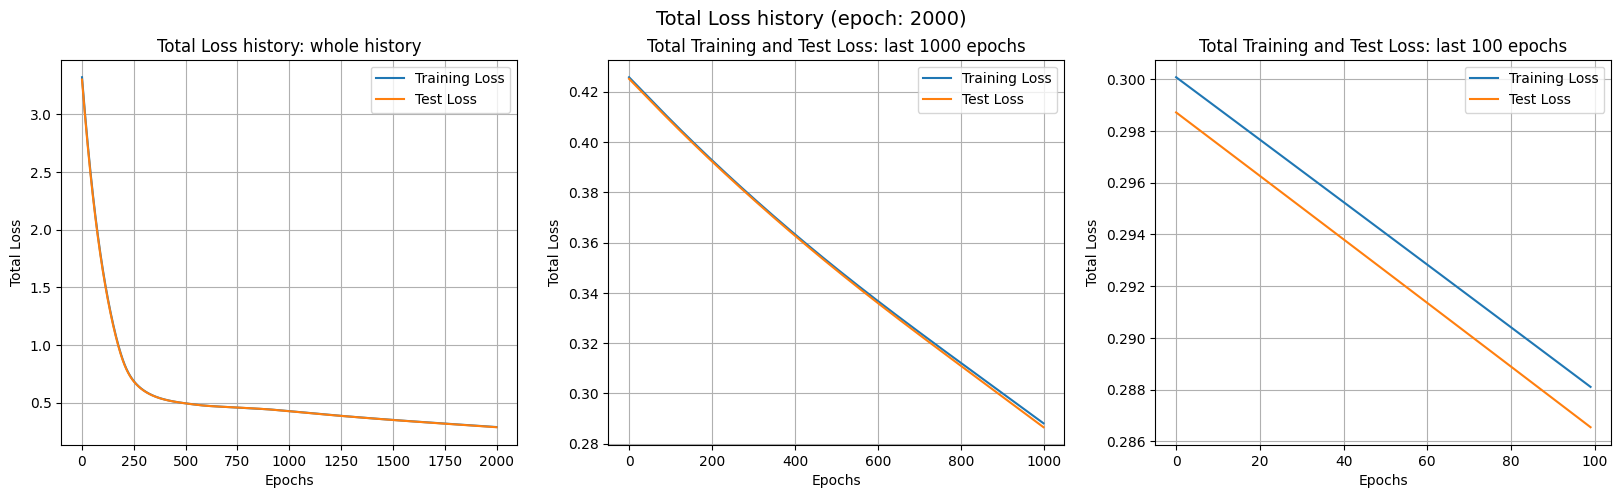

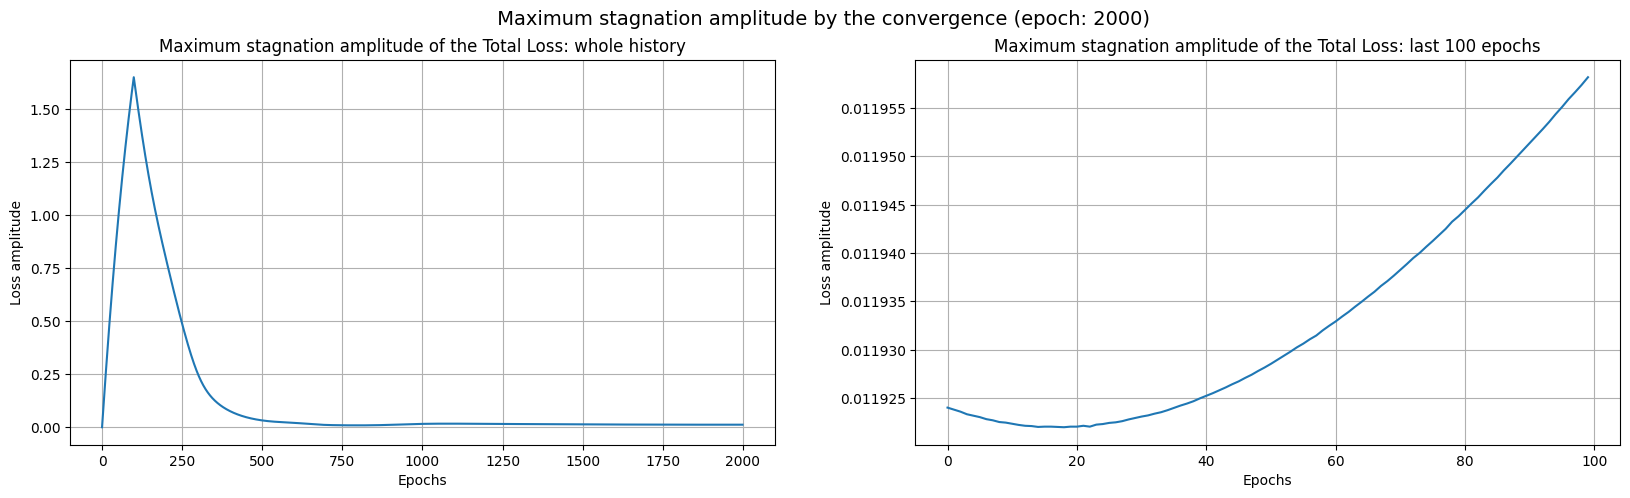

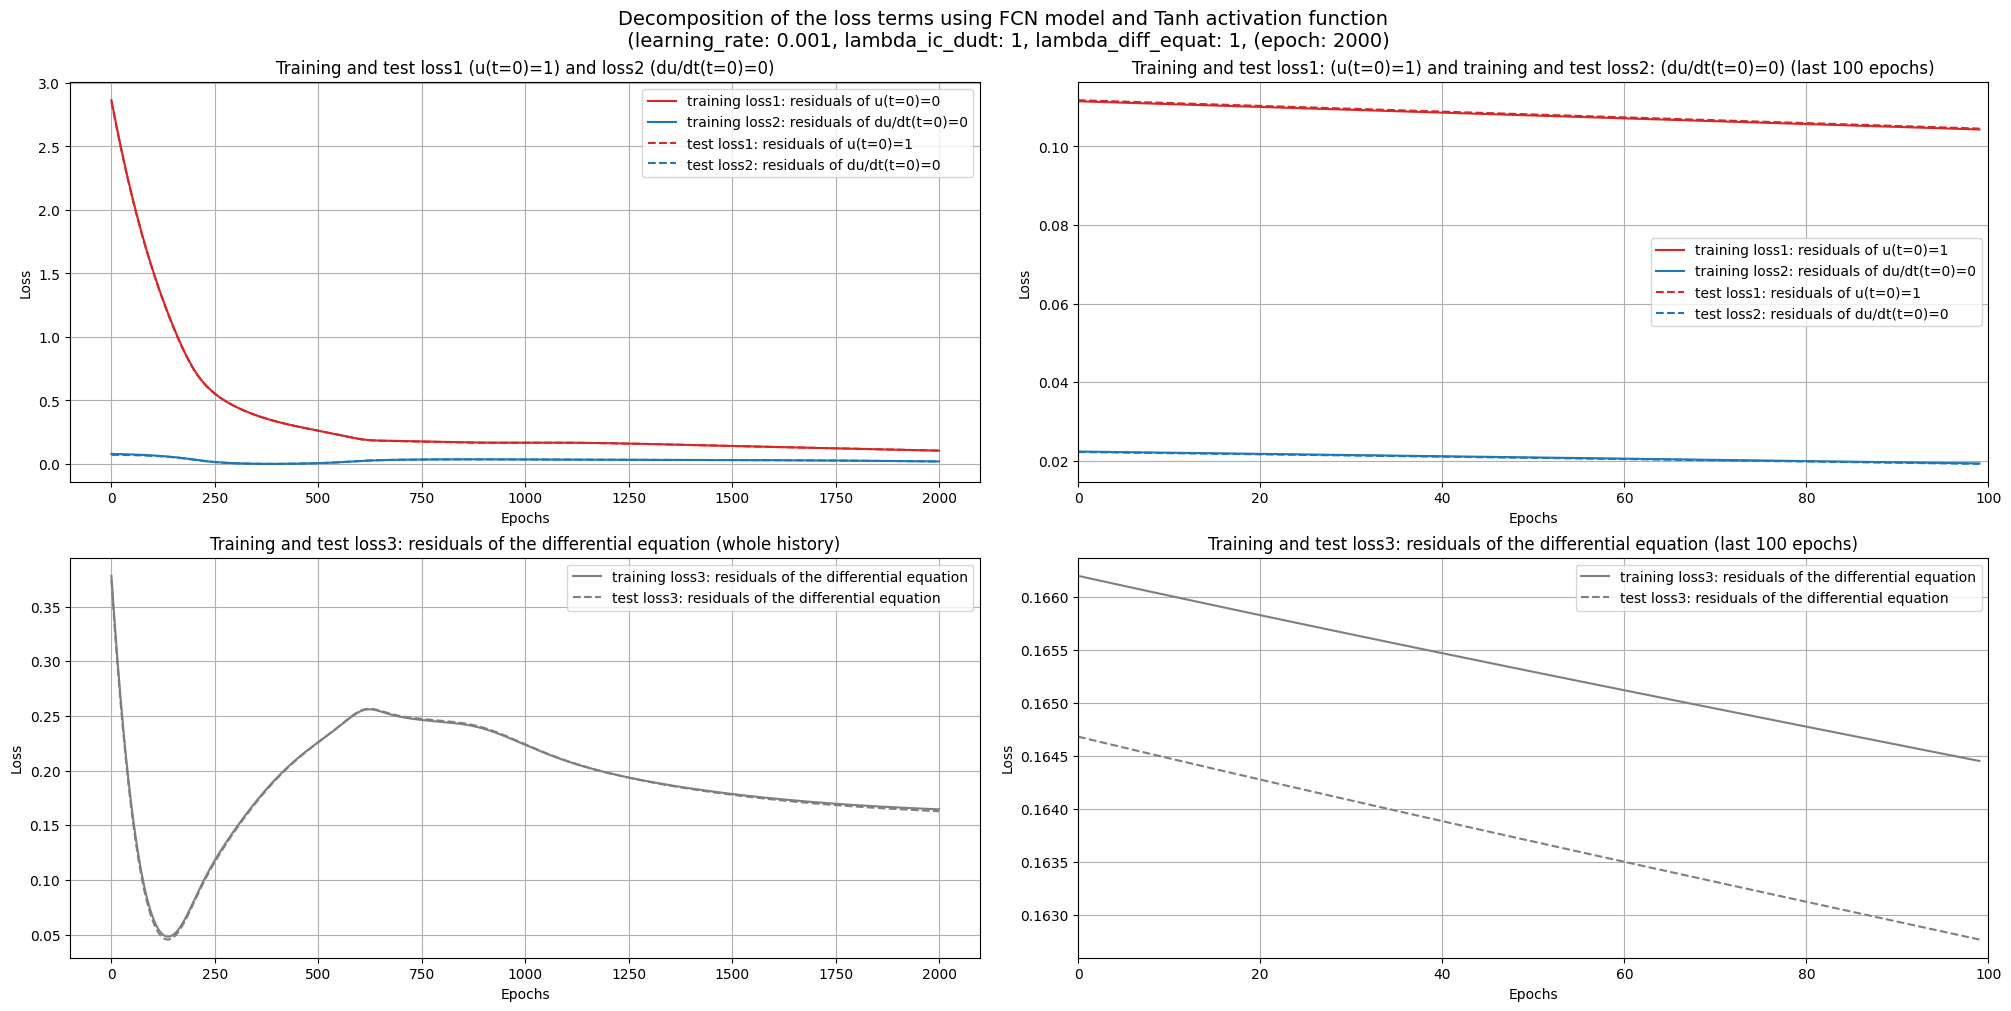

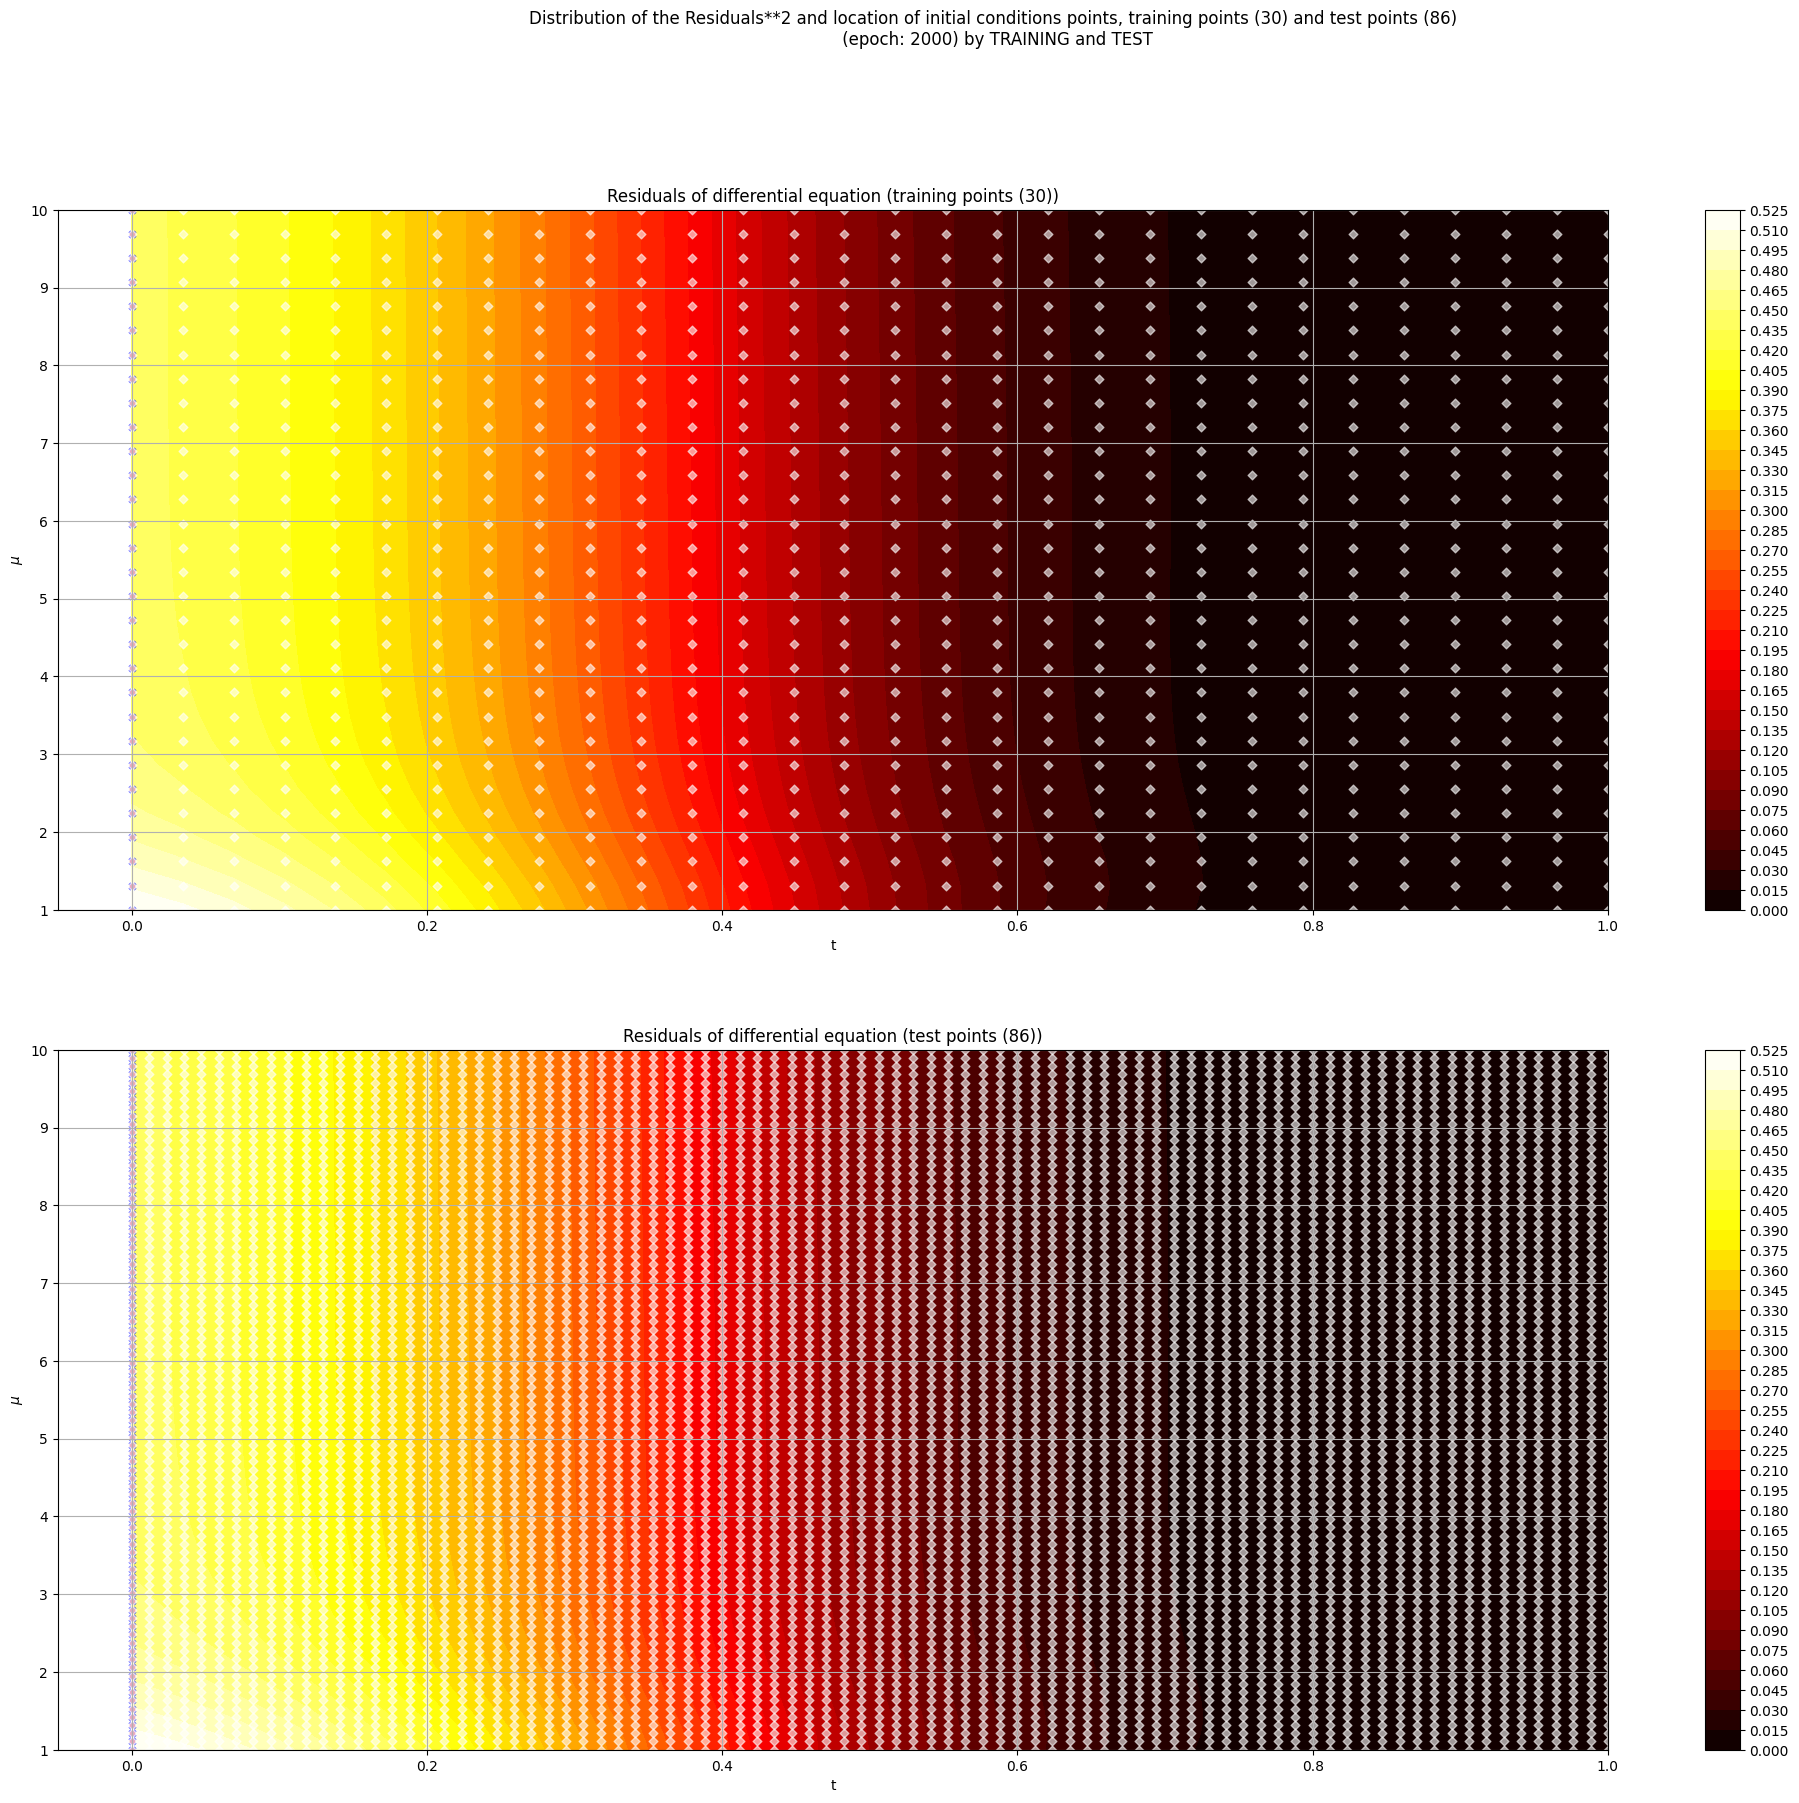

Saved the checkpoint corresponding to epoch: 2000
RESULTS PLOTTED FOR EPOCH: 2000
########################################################################################################################################################################################################
Training elapsed time (s): 14.479147911071777
Saved the checkpoint corresponding to last epoch: 2000


In [16]:
# Train original model
#train_model = TrainModel(original_model, num_epochs=1000, checkpoint_interval=100, loss_threshold=0.01)
#train_model = TrainModel(original_model, ic1_t_mu, ic1_scope, ic2_scope, physic_domain_t_mu, k, learning_rate = 0.0001, num_epochs= 20000, lambda_ic_dudt= 1e-1, lambda_diff_equat = 1e-4, checkpoint_interval = 1000, stagnation_amplitude= 0.0001, stagnation_range = 200)
#train_model = TrainModel(original_model, ic1_t_mu, ic1_scope, ic2_scope, physic_in_t_mu, physic_domain_t_mu, k, test_physic_in_t_mu, u_exact, test_mu = 5, learning_rate = 1e-2, num_epochs= 50000, lambda_ic_dudt= 1, lambda_diff_equat = 1e-4, checkpoint_interval = 1000, stagnation_amplitude= 0.00001, stagnation_range = 100)
train_model = training.TrainModel(original_model, original_input_size, original_hidden_layers, original_output_size, t_interval, ic1_t_mu, ic1_scope, ic2_t_mu, ic2_scope, physic_in_t_mu, physic_domain_t_mu, point_resolution, test_ic1_t_mu, test_ic1_scope, test_ic2_t_mu, test_ic2_scope, test_physic_in_t_mu, test_physic_domain_t_mu, test_point_resolution, u_exact= analytical_sol.exact_solution, test_mu = 5, mass = 1, w0 = 20, learning_rate = 1e-3, num_epochs= 2000, lambda_ic_dudt= 1, lambda_diff_equat = 1, checkpoint_interval = 1000, stagnation_amplitude= 1e-4, stagnation_range = 100)

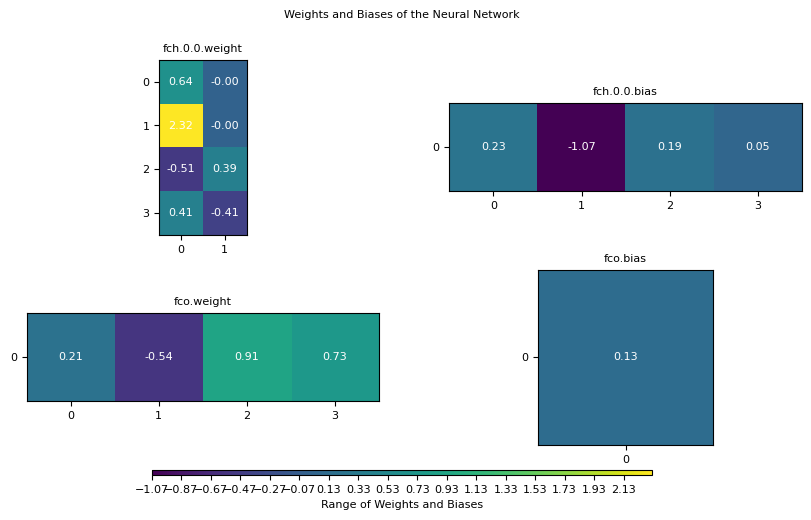

In [17]:
original_model.plot_weights(fig_size = (10,5), font_size = 8)

In [18]:
k

400

## STEP 5: Inference/Prediction with a constant mu

In [19]:
test_mu = 1
test_in_t_constant_mu = torch.stack([torch.linspace(0,1, test_point_resolution), test_mu*torch.ones(test_point_resolution)], -1).view(-1,2)
test_in_t_constant_mu.size

<function Tensor.size>

In [20]:
test_predicted = original_model(test_in_t_constant_mu)

In [21]:
u_exact = analytical_sol.exact_solution(test_mu/(2*mass), w0, test_physic_in_t_mu[0])

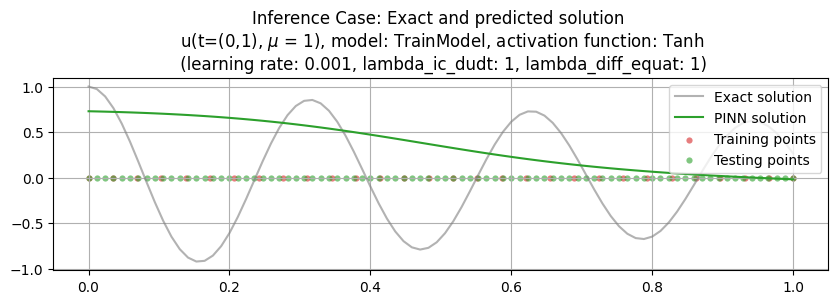

In [22]:
#u_test = pinn(test_t_frict_coeff_total).detach().cpu()
plt.figure(figsize=(10,2.5))

plt.plot(test_physic_in_t_mu[0].detach().numpy(), 
                 u_exact.detach().numpy(), 
                 label="Exact solution", 
                 color="tab:grey", 
                 alpha=0.6)
plt.plot(test_physic_in_t_mu[0].detach().numpy(), 
                 test_predicted[:,0].detach(), 
                 label="PINN solution", 
                 color="tab:green")
plt.scatter(
            physic_in_t_mu[0].detach().numpy(), 
            torch.zeros_like(physic_in_t_mu[0]), 
            s=20, 
            lw=0, 
            color="tab:red",
            alpha=0.6,
            label= "Training points")
plt.scatter(
            test_physic_in_t_mu[0].detach().numpy(), 
            torch.zeros_like(test_physic_in_t_mu[0]), 
            s=20, 
            lw=0, 
            color="tab:green",
            alpha=0.6,
            label= "Testing points")
plt.title(f"Inference Case: Exact and predicted solution \n u(t=(0,1), $\mu$ = {test_mu}), model: {train_model.__class__.__name__}, activation function: Tanh \n (learning rate: {train_model.learning_rate}, lambda_ic_dudt: {train_model.lambda_ic_dudt}, lambda_diff_equat: {train_model.lambda_diff_equat})")
#plt.title(f"Inference Case: Exact and predicted solution \n u(t=(0,1), $\mu$ = {train_model.test_mu}), model: {train_model.__class__.__name__}, activation function: Tanh \n (learning rate: {train_model.learning_rate}, lambda_ic_dudt: {train_model.lambda_ic_dudt}, lambda_diff_equat: {train_model.lambda_diff_equat})")

plt.grid()
plt.legend()
plt.show()

test_mu = 10

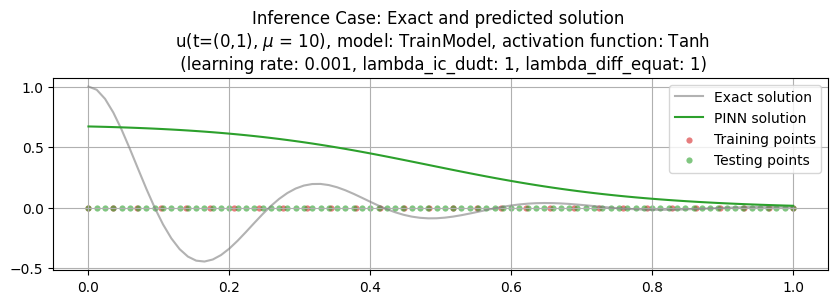

In [23]:
test_mu = 10
test_in_t_constant_mu = torch.stack([torch.linspace(0,1, test_point_resolution), test_mu*torch.ones(test_point_resolution)], -1).view(-1,2)
test_in_t_constant_mu.size
test_predicted = original_model(test_in_t_constant_mu)
u_exact = analytical_sol.exact_solution(test_mu/(2*mass), w0, test_physic_in_t_mu[0])
#u_test = pinn(test_t_frict_coeff_total).detach().cpu()
plt.figure(figsize=(10,2.5))

plt.plot(test_physic_in_t_mu[0].detach().numpy(), 
                 u_exact.detach().numpy(), 
                 label="Exact solution", 
                 color="tab:grey", 
                 alpha=0.6)
plt.plot(test_physic_in_t_mu[0].detach().numpy(), 
                 test_predicted[:,0].detach(), 
                 label="PINN solution", 
                 color="tab:green")
plt.scatter(
            physic_in_t_mu[0].detach().numpy(), 
            torch.zeros_like(physic_in_t_mu[0]), 
            s=20, 
            lw=0, 
            color="tab:red",
            alpha=0.6,
            label= "Training points")
plt.scatter(
            test_physic_in_t_mu[0].detach().numpy(), 
            torch.zeros_like(test_physic_in_t_mu[0]), 
            s=20, 
            lw=0, 
            color="tab:green",
            alpha=0.6,
            label= "Testing points")
plt.title(f"Inference Case: Exact and predicted solution \n u(t=(0,1), $\mu$ = {test_mu}), model: {train_model.__class__.__name__}, activation function: Tanh \n (learning rate: {train_model.learning_rate}, lambda_ic_dudt: {train_model.lambda_ic_dudt}, lambda_diff_equat: {train_model.lambda_diff_equat})")
#plt.title(f"Inference Case: Exact and predicted solution \n u(t=(0,1), $\mu$ = {train_model.test_mu}), model: {train_model.__class__.__name__}, activation function: Tanh \n (learning rate: {train_model.learning_rate}, lambda_ic_dudt: {train_model.lambda_ic_dudt}, lambda_diff_equat: {train_model.lambda_diff_equat})")

plt.grid()
plt.legend()
plt.show()